In [14]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import pandas as pd
import numpy as np
import datetime
import requests
import matplotlib.pyplot as plt
import streamlit as st

from Functions import BlackScholes, get_prices_opcions, get_all_chains, parse_chain

In [15]:
def get_risk_free_rate():
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": "TB3MS",  # 3-month T-bill
        "api_key": FRED_KEY,
        "sort_order": "desc",
        "limit": 1,
        "file_type": "json",
    }
    r = requests.get(url, params=params)
    rate = float(r.json()["observations"][0]["value"]) / 100
    return rate

In [16]:
ticker = "NVDA"


@st.cache_data
def real_BS_data(ticker):

    S = get_prices_opcions(ticker)[-1]
    df = parse_chain(get_all_chains(ticker))

    expiries = sorted(df["expiry"].unique())

    today = pd.Timestamp.today().normalize()
    expiries = [e for e in expiries if pd.to_datetime(e) > today]

    days = [(pd.to_datetime(e) - today).days for e in expiries]

    return {"S": S, "expiries": expiries, "days": days, "df": df}

2026-04-15 22:06:55.623 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [17]:
class MarketData:
    def __init__(self, ticker):
        self.ticker = ticker
        self.S = None
        self.df = None
        self.rate = None
        self.expiries = None

    def load(self):
        self.S = get_prices_opcions(self.ticker)[-1]
        self.df = parse_chain(get_all_chains(self.ticker))
        self.rate = get_risk_free_rate()
        self.expiries = self.df["expiry"].unique()
        return self


def get_otm_option(df, S, expiry, call=True):
    if call:
        df = df[(df["type"] == "call") & (df["strike"] > S)]
    else:
        df = df[(df["type"] == "put") & (df["strike"] < S)]

    return df.iloc[(df["strike"] - S).abs().argsort()[:1]]

In [18]:
results = real_BS_data("NVDA")
df = results["df"]
df[
    (df["type"] == "call")
    & (df["expiry"] == results["expiries"][3])
    & (df["strike"] > results["S"])
]
# info= df[["expiry","stike","last"]]
# info

2026-04-15 22:06:56.776 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-15 22:06:56.788 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


,expiry,strike,type,mid,iv,delta,gamma,theta,vega,volume,oi,bid,ask,last
558,2026-04-24,200.0,call,3.575,0.3308,0.4658,0.0382,-0.2341,0.1242,43185.0,22897.0,3.55,3.60,3.56
560,2026-04-24,202.5,call,2.535,0.3261,0.3713,0.0369,-0.2183,0.1182,50093.0,4456.0,2.52,2.55,2.53
562,2026-04-24,205.0,call,1.730,0.3233,0.2839,0.0334,-0.1924,0.1062,31258.0,14428.0,1.72,1.74,1.72
564,2026-04-24,207.5,call,1.160,0.3234,0.2099,0.0284,-0.1616,0.0906,37101.0,731.0,1.15,1.17,1.16
566,2026-04-24,210.0,call,0.775,0.3269,0.1514,0.0229,-0.1309,0.0741,33661.0,4765.0,0.77,0.78,0.77
568,2026-04-24,212.5,call,0.525,0.3335,0.1086,0.0178,-0.1043,0.0590,3119.0,2060.0,0.52,0.53,0.49
570,2026-04-24,215.0,call,0.365,0.3429,0.0787,0.0136,-0.0832,0.0467,3790.0,4206.0,0.36,0.37,0.34
572,2026-04-24,220.0,call,0.195,0.3679,0.0444,0.0081,-0.0554,0.0299,2965.0,5116.0,0.19,0.20,0.20
574,2026-04-24,225.0,call,0.125,0.4014,0.0275,0.0050,-0.0395,0.0203,685.0,4083.0,0.12,0.13,0.13
576,2026-04-24,230.0,call,0.075,0.4268,0.0182,0.0033,-0.0293,0.0143,733.0,4285.0,0.07,0.08,0.08


In [19]:
def chain_buy_sell(results, date):

    df = results["df"]
    df = df[df["expiry"] == date]
    df = df[["strike", "type", "bid", "ask", "last"]]

    calls_df = df[df["type"] == "call"]
    puts_df = df[df["type"] == "put"]
    strikes_df = calls_df[["strike"]].reset_index(drop=True)

    calls_df = calls_df[["bid", "ask", "last"]].reset_index(drop=True)
    puts_df = puts_df[["bid", "ask", "last"]].reset_index(drop=True)

    calls_df.columns = [c + " (c)" for c in calls_df.columns]
    puts_df.columns = [c + " (p)" for c in puts_df.columns]

    chain = pd.concat([calls_df, strikes_df, puts_df], axis=1)

    return chain

In [20]:
chain = chain_buy_sell(results, "2026-04-17")
chain

,bid (c),ask (c),last (c),strike,bid (p),ask (p),last (p)
0,191.90,195.10,191.33,5.0,0.00,0.01,0.01
1,186.50,190.70,188.34,10.0,0.00,0.01,0.01
2,181.50,184.80,181.74,15.0,0.00,0.01,0.01
3,176.75,180.45,176.76,20.0,0.00,0.01,0.01
4,171.70,175.45,171.88,25.0,0.00,0.01,0.01
...,...,...,...,...,...,...,...
111,0.00,0.01,0.01,380.0,180.20,183.20,0.00
112,0.00,0.01,0.01,390.0,190.25,193.20,0.00
113,0.00,0.01,0.01,400.0,200.40,203.20,0.00
114,0.00,0.01,0.01,410.0,210.25,213.20,0.00


In [ ]:
class OptionPricing:
    def __init__(self, options):
        self.options = options

    def net_premium(self):
        return sum([bs.price() * trade for bs, trade in self.options])

    def payoff(self, spot):
        return sum(bs.payoff_at_expiry(spot) * trade for bs, trade in self.options)

    def PnL(self, spot):
        return self.payoff(spot) - self.net_premium()

    def max_loss(self):
        spots, pnls = self.get_spots()
        max_loss = round(min(pnls), 2)

        return max_loss

    def max_profit(self):
        spots, pnls = self.get_spots()
        max_profit = round(max(pnls), 2)

        return max_profit

    def break_even(self):
        spots, pnls = self.get_spots()
        break_even_pos = np.where(np.diff(np.signbit(pnls)))[0]

        return spots[break_even_pos]

    def get_spots(self):
        k = self.options[0][0].K
        spots = np.linspace(k * 0.5, k * 2, 200)
        pnls = [self.PnL(spot) for spot in spots]

        return spots, pnls

    def resume(self):
        print(
            f"max loss: {self.max_loss()}, max profit: {self.max_profit()}, break even: {self.break_even()}"
        )

    def plotgraph(self):
        spots, pnls = self.get_spots()

        plt.figure(figsize=(10, 5))
        plt.plot(spots, pnls)
        plt.axhline(0, color="black", linewidth=1)

        plt.title("Strategy P&L")
        plt.xlabel("Spot")
        plt.ylabel("P&L")

        plt.show()

    def debugg(self):
        print(self.options)
        print(len(self.options))
        return sum(bs.price() * trade for bs, trade in self.options)

    def multiplotgraph(self):

        plt.figure(figsize=(10, 5))

        for bs, trade in self.options:
            spots = np.linspace(0, bs.K * 2, 300)
            pnl = [trade * (bs.payoff_at_expiry(s) - bs.price()) for s in spots]
            plt.plot(spots, pnl)

        plt.axhline(0, color="black", linewidth=1)

        plt.title("Strategy P&L")
        plt.xlabel("Spot")
        plt.ylabel("P&L")

        plt.show()

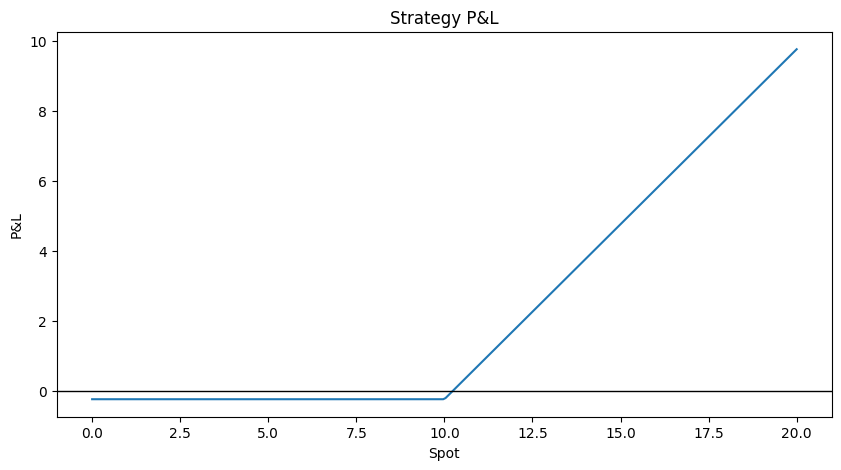

0.24303675391132007

In [26]:
bs3 = BlackScholes(10, 10, 30, 0.035, 0.20, call=True)
bs4 = BlackScholes(10, 10, 30, 0.035, 0.20, call=False)
bstry = OptionPricing([(bs3, 1)])
bstry.multiplotgraph()
bstry.net_premium()

In [ ]:
bs1 = BlackScholes(10, 8, 30, 0.035, 0.20, call=False)
bs2 = BlackScholes(10, 9, 30, 0.035, 0.20, call=False)
bs3 = BlackScholes(10, 11, 30, 0.035, 0.20, call=True)
bs4 = BlackScholes(10, 12, 30, 0.035, 0.20, call=True)

opt = OptionPricing([(bs1, -1), (bs2, 1), (bs3, 1), (bs4, -1)])

opt.plotgraph()
opt.resume()

In [ ]:
class OptionPricing:
    def __init__(self, md, orders):
        self.md = md  # class with inmportant values
        self.orders = orders  # list with list of orders

    def net_premium(self):
        return sum([bs.price() * trade for bs, trade in self.orders])

    def payoff(self, spot):
        return sum(bs.payoff_at_expiry(spot) * trade for bs, trade in self.orders)

    def PnL(self, spot):
        return self.payoff(spot) - self.net_premium()

    def debugg(self):
        print(self.orders)
        print(len(self.orders))
        return sum(bs.price() * trade for bs, trade in self.orders)

    def max_loss(self):
        spots, pnls = self.get_spots()
        max_loss = round(min(pnls), 2)

        return max_loss

    def max_profit(self):
        spots, pnls = self.get_spots()
        max_profit = round(max(pnls), 2)

        return max_profit

    def break_even(self):
        spots, pnls = self.get_spots()
        break_even_pos = np.where(np.diff(np.signbit(pnls)))[0]

        return spots[break_even_pos]

    def get_spots(self):
        k = self.orders[0][0].K
        spots = np.linspace(k * 0.5, k * 2, 200)
        pnls = [self.PnL(spot) for spot in spots]

        return spots, pnls

    def resume(self):
        print(
            f"max loss: {self.max_loss()}, max profit: {self.max_profit()}, break even: {self.break_even()}"
        )

    def plotgraph(self):
        spots, pnls = self.get_spots()

        plt.figure(figsize=(10, 5))
        plt.plot(spots, pnls)
        plt.axhline(0, color="black", linewidth=1)

        plt.title("Strategy P&L")
        plt.xlabel("Spot")
        plt.ylabel("P&L")

        plt.show()

    def multiplotgraph(self):

        plt.figure(figsize=(10, 5))

        for bs, trade in self.orders:
            spots = np.linspace(0, bs.K * 2, 300)
            pnl = [trade * (bs.payoff_at_expiry(s) - bs.price()) for s in spots]
            plt.plot(spots, pnl)

        plt.axhline(0, color="black", linewidth=1)

        plt.title("Strategy P&L")
        plt.xlabel("Spot")
        plt.ylabel("P&L")

        plt.show()